<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [3]:
# Load the data
# The first column doesn't have an accurate name, so rename it then set as index
df = pd.read_csv('data/College.csv')
df = df.rename(columns={'Unnamed: 0': 'College'})
df = df.set_index('College')
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [4]:
# Check the shape, data types, and missing values
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (777, 18)

Data types:
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

Missing values per column:
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64


#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [5]:
# Fix the PhD column
# PhD column has entries like '???', 'XXXX', etc.
print(df['PhD'].value_counts().head(20))

# Convert to numeric, coerce errors to NaN
df['PhD'] = pd.to_numeric(df['PhD'], errors='coerce')

# Fill NaN with the median
df['PhD'] = df['PhD'].fillna(df['PhD'].median())

print(df['PhD'].describe())

PhD
?     29
77    26
73    24
90    22
71    21
75    21
82    20
76    19
89    19
79    19
81    19
78    18
62    18
88    18
74    17
87    17
80    17
84    17
91    17
93    16
Name: count, dtype: int64
count    777.000000
mean      72.611326
std       16.014355
min        8.000000
25%       62.000000
50%       75.000000
75%       85.000000
max      103.000000
Name: PhD, dtype: float64


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [6]:
# Fix the Grad.Rate column
# Grad.Rate may have values > 100 which is impossible for a percentage
print("Max Grad.Rate before fix:", df['Grad.Rate'].max())

# Convert to numeric, coerce errors
df['Grad.Rate'] = pd.to_numeric(df['Grad.Rate'], errors='coerce')

# Cap at 100
df['Grad.Rate'] = df['Grad.Rate'].clip(upper=100)

# Fill any remaining NaN with median
df['Grad.Rate'] = df['Grad.Rate'].fillna(df['Grad.Rate'].median())

print("Max Grad.Rate after fix:", df['Grad.Rate'].max())

Max Grad.Rate before fix: 118
Max Grad.Rate after fix: 100


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [7]:
%%writefile myutils.py
def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    import pandas as pd
    import numpy as np
    
    results = []
    
    for col in df.select_dtypes(include=[np.number]).columns:
        
        if df[col].nunique() <= 2:
            continue
        
        skew_val = df[col].skew()
        
        # Classify degree and direction
        if skew_val < -1:
            degree = "Highly Skewed"
            direction = "Negative"
        elif skew_val < -0.5:
            degree = "Moderately Skewed"
            direction = "Negative"
        elif skew_val <= 0.5:
            degree = "Approximately Symmetric"
            direction = "Negative" if skew_val < 0 else "Positive"
        elif skew_val <= 1:
            degree = "Moderately Skewed"
            direction = "Positive"
        else:
            degree = "Highly Skewed"
            direction = "Positive"
        
        # Recommend transformation
        if abs(skew_val) <= 0.5:
            rec = "None needed"
        elif degree == "Highly Skewed" and direction == "Positive":
            rec = "Box-Cox or Yeo-Johnson"
        elif degree == "Moderately Skewed" and direction == "Positive":
            rec = "Box-Cox or Yeo-Johnson"
        elif degree == "Moderately Skewed" and direction == "Negative":
            rec = "Box-Cox or Yeo-Johnson"
        elif degree == "Highly Skewed" and direction == "Negative":
            rec = "Box-Cox or Yeo-Johnson"
        else:
            rec = "log(x+1) or Yeo-Johnson"
        
        # Refine: log(x+1) for highly positive skewed data that includes zero
        if direction == "Positive" and degree == "Highly Skewed" and df[col].min() == 0:
            rec = "log(x+1) or Yeo-Johnson"
        
        results.append({
            'Feature': col,
            'Skewness': round(skew_val, 6),
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': rec
        })
    
    return pd.DataFrame(results)

Overwriting myutils.py


In [8]:
# Now import the function from myutils
from myutils import skew_calc

In [12]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
    from sklearn.preprocessing import PowerTransformer
    import numpy as np
    
    skewed_cols = skew_table[skew_table['Recommended Transformation'] != 'None needed']['Feature'].values
    
    n_cols = len(skewed_cols)
    fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4 * n_cols))
    
    if n_cols == 1:
        axes = axes.reshape(1, 2)
    
    for i, col in enumerate(skewed_cols):
        # Original
        axes[i, 0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i, 0].set_title(f'{col} (Original)\nSkewness: {df[col].skew():.2f}')
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel('Frequency')
        
        # Apply transformation - use Yeo-Johnson for all to avoid positivity constraint
        data = df[col].dropna().values.reshape(-1, 1)
        pt = PowerTransformer(method='yeo-johnson')
        transformed = pt.fit_transform(data)
        
        # Transformed
        axes[i, 1].hist(transformed, bins=30, edgecolor='black', alpha=0.7, color='green')
        axes[i, 1].set_title(f'{col} (Transformed)\nSkewness: {pd.Series(transformed.flatten()).skew():.2f}')
        axes[i, 1].set_xlabel(col + ' (transformed)')
        axes[i, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [9]:
# Call skew_calc and display the table
skew_table = skew_calc(df)
skew_table

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


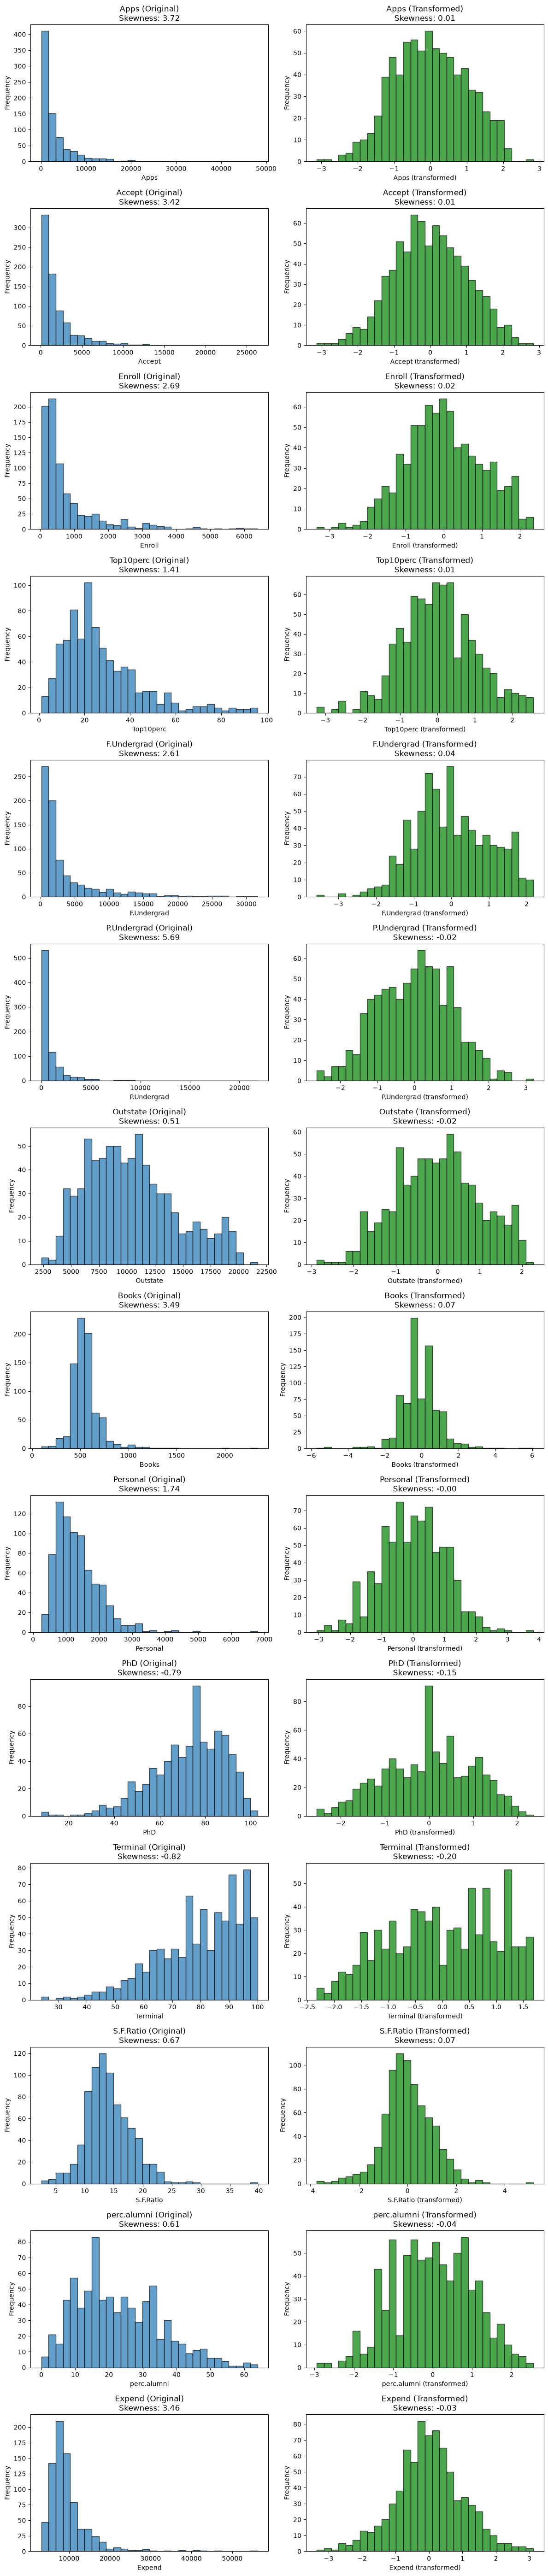

In [13]:
# Call plot_transformations
plot_transformations(df, skew_table)

In [14]:
# Run the transformations on the data using PowerTransformer
from sklearn.preprocessing import PowerTransformer

skewed_cols = skew_table[skew_table['Recommended Transformation'] != 'None needed']['Feature'].values
print(f"Skewed columns to transform: {list(skewed_cols)}")

Skewed columns to transform: ['Apps', 'Accept', 'Enroll', 'Top10perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend']


In [12]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [15]:
trans_cols = []

# Your code here 
skewed_cols = skew_table[skew_table['Recommended Transformation'] != 'None needed']['Feature'].values

for col in skewed_cols:
    data = df[col].dropna().values.reshape(-1, 1)
    # Use Yeo-Johnson for all columns to avoid the strict positivity constraint of Box-Cox
    pt = PowerTransformer(method='yeo-johnson')
    transformed = pt.fit_transform(data)
    new_col_name = f'{col}_transformed'
    df[new_col_name] = transformed
    trans_cols.append(new_col_name)

print(f"Created {len(trans_cols)} transformed columns: {trans_cols}")

Created 14 transformed columns: ['Apps_transformed', 'Accept_transformed', 'Enroll_transformed', 'Top10perc_transformed', 'F.Undergrad_transformed', 'P.Undergrad_transformed', 'Outstate_transformed', 'Books_transformed', 'Personal_transformed', 'PhD_transformed', 'Terminal_transformed', 'S.F.Ratio_transformed', 'perc.alumni_transformed', 'Expend_transformed']


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [16]:
# Engineer Accept_Rate feature
df['Accept_Rate'] = df['Accept'] / df['Apps']
df['Accept_Rate'].describe()

count    777.000000
mean       0.746928
std        0.147104
min        0.154486
25%        0.675647
50%        0.778750
75%        0.848522
max        1.000000
Name: Accept_Rate, dtype: float64

#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [17]:
# Bin Outstate into tiers
df['Outstate_Tier'] = pd.cut(df['Outstate'], 
                              bins=[0, 5000, 10000, 15000, 20000, 50000],
                              labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
df['Outstate_Tier'].value_counts()

Outstate_Tier
Low          340
Medium       267
High         114
Very Low      54
Very High      2
Name: count, dtype: int64

#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [18]:
# Ordinally encode Outstate_Tier
tier_map = {'Very Low': 1, 'Low': 2, 'Medium': 3, 'High': 4, 'Very High': 5}
df['Outstate_Tier_Encoded'] = df['Outstate_Tier'].map(tier_map)
df[['Outstate', 'Outstate_Tier', 'Outstate_Tier_Encoded']].head(10)

,Outstate,Outstate_Tier,Outstate_Tier_Encoded
College,,,
Abilene Christian University,7440,Low,2
Adelphi University,12280,Medium,3
Adrian College,11250,Medium,3
Agnes Scott College,12960,Medium,3
Alaska Pacific University,7560,Low,2
Albertson College,13500,Medium,3
Albertus Magnus College,13290,Medium,3
Albion College,13868,Medium,3
Albright College,15595,High,4


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [19]:
# Binary encode Private
df['Private_Encoded'] = df['Private'].map({'Yes': 1, 'No': 0})
df[['Private', 'Private_Encoded']].head()

,Private,Private_Encoded
College,,
Abilene Christian University,Yes,1
Adelphi University,Yes,1
Adrian College,Yes,1
Agnes Scott College,Yes,1
Alaska Pacific University,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [20]:
cols_to_scale = []

# Scale the transformed columns + encoded features
cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_Encoded', 'Private_Encoded']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[cols_to_scale])

# Create scaled column names
scaled_col_names = [col + '_scaled' for col in cols_to_scale]
df[scaled_col_names] = df_scaled

print(f"Scaled {len(scaled_col_names)} columns: {scaled_col_names}")

Scaled 17 columns: ['Apps_transformed_scaled', 'Accept_transformed_scaled', 'Enroll_transformed_scaled', 'Top10perc_transformed_scaled', 'F.Undergrad_transformed_scaled', 'P.Undergrad_transformed_scaled', 'Outstate_transformed_scaled', 'Books_transformed_scaled', 'Personal_transformed_scaled', 'PhD_transformed_scaled', 'Terminal_transformed_scaled', 'S.F.Ratio_transformed_scaled', 'perc.alumni_transformed_scaled', 'Expend_transformed_scaled', 'Accept_Rate_scaled', 'Outstate_Tier_Encoded_scaled', 'Private_Encoded_scaled']


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

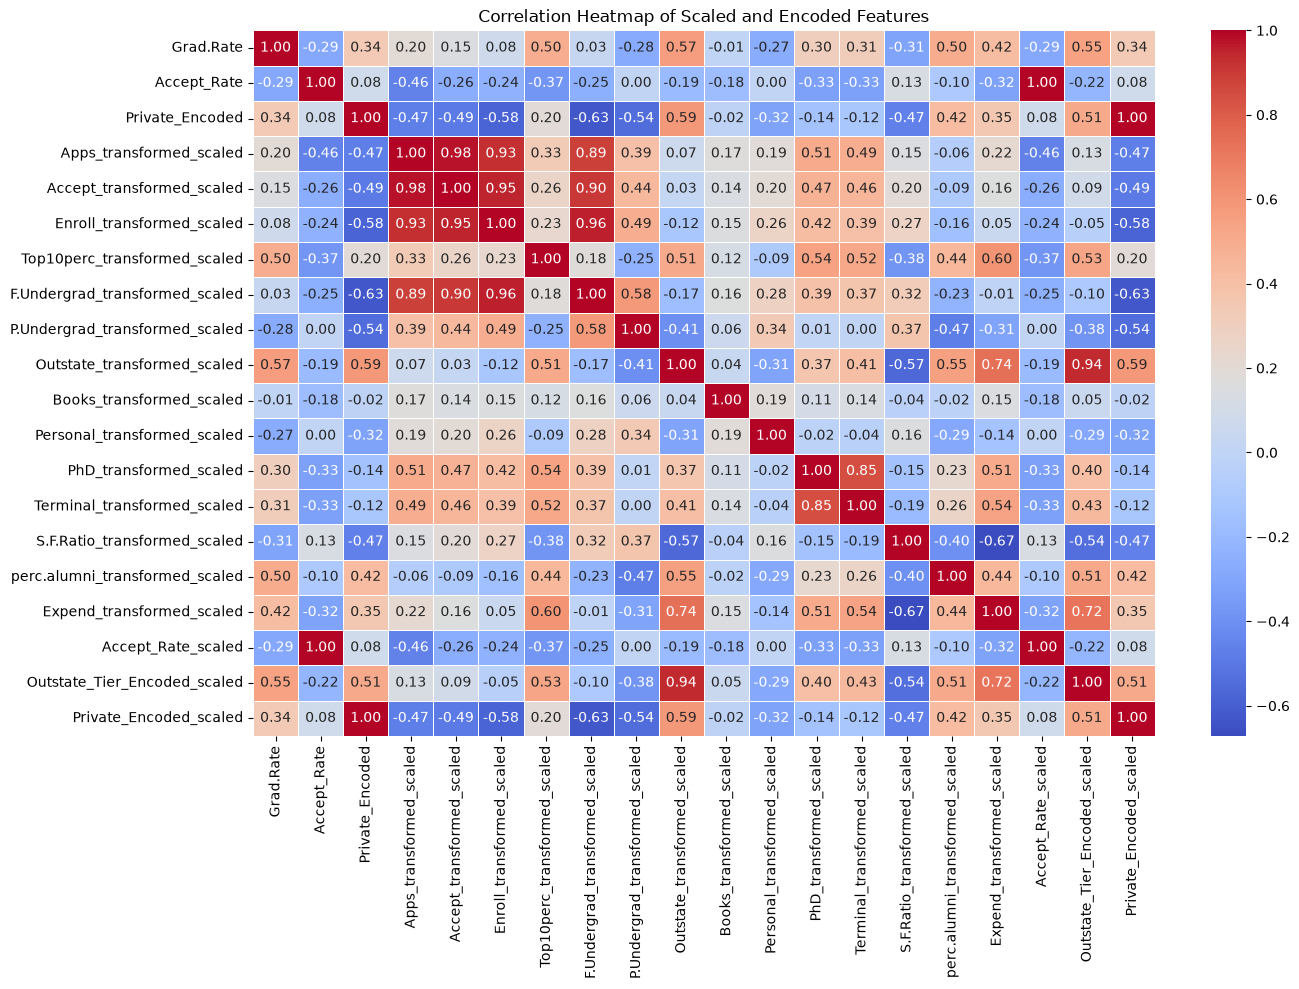


Correlation with Grad.Rate:
Grad.Rate                         1.000000
Outstate_transformed_scaled       0.569032
Outstate_Tier_Encoded_scaled      0.547790
perc.alumni_transformed_scaled    0.500899
Top10perc_transformed_scaled      0.495057
Expend_transformed_scaled         0.417199
Private_Encoded                   0.336490
Private_Encoded_scaled            0.336490
Terminal_transformed_scaled       0.310558
PhD_transformed_scaled            0.303732
Apps_transformed_scaled           0.202305
Accept_transformed_scaled         0.147992
Enroll_transformed_scaled         0.078218
F.Undergrad_transformed_scaled    0.033351
Books_transformed_scaled         -0.005477
Personal_transformed_scaled      -0.269857
P.Undergrad_transformed_scaled   -0.277715
Accept_Rate_scaled               -0.289299
Accept_Rate                      -0.289299
S.F.Ratio_transformed_scaled     -0.310931
Name: Grad.Rate, dtype: float64


In [21]:
# Plot a correlation heatmap
# Include numeric columns plus the new scaled features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude individual transformed columns if scaled versions exist
cols_for_heatmap = [c for c in numeric_cols if '_scaled' in c or c in ['Grad.Rate', 'Accept_Rate', 'Outstate_Tier_Encoded', 'Private_Encoded']]

plt.figure(figsize=(14, 10))
sns.heatmap(df[cols_for_heatmap].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Scaled and Encoded Features')
plt.tight_layout()
plt.show()

# Features most related to Grad.Rate
print("\nCorrelation with Grad.Rate:")
print(df[cols_for_heatmap].corr()['Grad.Rate'].sort_values(ascending=False))

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [21]:
# Split data for modeling: target is Grad.Rate

# Untransformed predictors (raw numeric features, no transformed versions)
untransformed_predictors = ['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 
                            'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
                            'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio',
                            'perc.alumni', 'Expend', 'Private_Encoded', 'Accept_Rate',
                            'Outstate_Tier_Encoded']

# Transformed predictors (using scaled transformed versions)
transformed_predictors = scaled_col_names  # Already have the scaled cols

# Make sure all columns exist
untransformed_predictors = [c for c in untransformed_predictors if c in df.columns]
transformed_predictors = [c for c in transformed_predictors if c in df.columns]

print(f"Untransformed predictors ({len(untransformed_predictors)}): {untransformed_predictors}")
print(f"Transformed predictors ({len(transformed_predictors)}): {transformed_predictors}")

Untransformed predictors (19): ['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Private_Encoded', 'Accept_Rate', 'Outstate_Tier_Encoded']
Transformed predictors (17): ['Apps_transformed_scaled', 'Accept_transformed_scaled', 'Enroll_transformed_scaled', 'Top10perc_transformed_scaled', 'F.Undergrad_transformed_scaled', 'P.Undergrad_transformed_scaled', 'Outstate_transformed_scaled', 'Books_transformed_scaled', 'Personal_transformed_scaled', 'PhD_transformed_scaled', 'Terminal_transformed_scaled', 'S.F.Ratio_transformed_scaled', 'perc.alumni_transformed_scaled', 'Expend_transformed_scaled', 'Accept_Rate_scaled', 'Outstate_Tier_Encoded_scaled', 'Private_Encoded_scaled']


#### 15. Fit a linear regression using the raw predictors


In [22]:
untrans_predictors = []

# Fit a linear regression using the raw predictors
untrans_predictors = [c for c in untransformed_predictors if c in df.columns]

X_untrans = df[untrans_predictors].dropna()
y_untrans = df.loc[X_untrans.index, 'Grad.Rate']

Xut_train, Xut_test, yut_train, yut_test = train_test_split(
    X_untrans, y_untrans, test_size=0.2, random_state=42)

lr_untrans = LinearRegression()
lr_untrans.fit(Xut_train, yut_train)

yut_pred = lr_untrans.predict(Xut_test)
r2_untrans = r2_score(yut_test, yut_pred)
print(f"Untransformed model R2: {r2_untrans:.4f}")

Untransformed model R2: 0.4637


#### 16. Fit the same model using the log-transformed predictors

In [23]:
trans_predictors = []

# Fit the same model using the transformed predictors
trans_predictors = [c for c in transformed_predictors if c in df.columns]

X_trans = df[trans_predictors].dropna()
y_trans = df.loc[X_trans.index, 'Grad.Rate']

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_trans, y_trans, test_size=0.2, random_state=42)

lr_trans = LinearRegression()
lr_trans.fit(Xt_train, yt_train)

yt_pred = lr_trans.predict(Xt_test)
r2_trans = r2_score(yt_test, yt_pred)
print(f"Transformed model R2: {r2_trans:.4f}")

Transformed model R2: 0.4761


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [24]:
# Compare the two R-squared scores
print("=== Model Comparison ===")
print(f"Untransformed Predictors R²: {r2_untrans:.4f}")
print(f"Transformed Predictors R²: {r2_trans:.4f}")
print(f"Improvement: {((r2_trans - r2_untrans) / abs(r2_untrans)) * 100:.2f}%")

if r2_trans > r2_untrans:
    print("\nThe transformation improved the model's predictive performance.")
else:
    print("\nThe transformation did not significantly improve the model. The raw predictors may already capture the linear relationships well.")

=== Model Comparison ===
Untransformed Predictors R²: 0.4637
Transformed Predictors R²: 0.4761
Improvement: 2.67%

The transformation improved the model's predictive performance.


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [25]:
# Export the cleaned and transformed DataFrame to CSV
df.to_csv('college_transformed.csv', index=True)
print("Exported to college_transformed.csv")

Exported to college_transformed.csv
